**Scenario 1**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import NMF
from collections import defaultdict

In [12]:
df = pd.read_csv(r'D:\SEM4\ml\lab\dataset\10th\ratings.csv')
movies_df = pd.read_csv(r'D:\SEM4\ml\lab\dataset\10th\movies.csv') 

print(df.head())

   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205


In [13]:
user_movie_matrix = df.pivot(index='userId', columns='movieId', values='rating')
user_ratings_mean = np.nanmean(user_movie_matrix.values, axis=1)

R_demeaned = user_movie_matrix.values - user_ratings_mean.reshape(-1, 1)
R_demeaned = np.nan_to_num(R_demeaned)

print(f"Shape of the User-Item Matrix: {user_movie_matrix.shape}")

Shape of the User-Item Matrix: (671, 9066)


In [14]:
k_factors = 20
U, sigma, Vt = svds(R_demeaned, k=k_factors)
sigma = np.diag(sigma)

predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
preds_df = pd.DataFrame(predicted_ratings, columns=user_movie_matrix.columns, index=user_movie_matrix.index)

In [15]:
def recommend_movies(predictions_df, userID, original_ratings_df, movies_df, num_recommendations=5):
    user_row_number = userID
    sorted_user_predictions = predictions_df.loc[user_row_number].sort_values(ascending=False)
    
    user_data = original_ratings_df[original_ratings_df.userId == userID]

    user_full = (user_data.merge(movies_df, how='left', on='movieId').
                 sort_values(['rating'], ascending=False))
    
    recommendations = (movies_df[~movies_df['movieId'].isin(user_full['movieId'])]).merge(
        pd.DataFrame(sorted_user_predictions).reset_index(), how='left', on='movieId')
    
    recommendations = recommendations.rename(columns={user_row_number: 'Predictions'})
    recommendations = recommendations.sort_values('Predictions', ascending=False).iloc[:num_recommendations, :]
    
    return user_full, recommendations

already_rated, predictions = recommend_movies(preds_df, 1, df, movies_df, 5)
print("Top 5 Recommendations for User 1:\n", predictions)

Top 5 Recommendations for User 1:
      movieId                                              title  \
744      924                       2001: A Space Odyssey (1968)   
521      589                  Terminator 2: Judgment Day (1991)   
265      296                                Pulp Fiction (1994)   
957     1206                         Clockwork Orange, A (1971)   
625      750  Dr. Strangelove or: How I Learned to Stop Worr...   

                          genres  Predictions  
744       Adventure|Drama|Sci-Fi     2.584749  
521                Action|Sci-Fi     2.573286  
265  Comedy|Crime|Drama|Thriller     2.571196  
957  Crime|Drama|Sci-Fi|Thriller     2.570730  
625                   Comedy|War     2.570274  


In [16]:
def calculate_errors(actual_matrix, predicted_matrix):
    mask = ~np.isnan(actual_matrix)
    actual_values = actual_matrix[mask]
    predicted_values = predicted_matrix[mask]
    
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    mae = mean_absolute_error(actual_values, predicted_values)
    return rmse, mae

k_values = [5, 10, 20, 50, 100]
rmse_list = []
mae_list = []

for k in k_values:
    U_k, sigma_k, Vt_k = svds(R_demeaned, k=k)
    sigma_k = np.diag(sigma_k)
    pred_k = np.dot(np.dot(U_k, sigma_k), Vt_k) + user_ratings_mean.reshape(-1, 1)
    
    rmse, mae = calculate_errors(user_movie_matrix.values, pred_k)
    rmse_list.append(rmse)
    mae_list.append(mae)

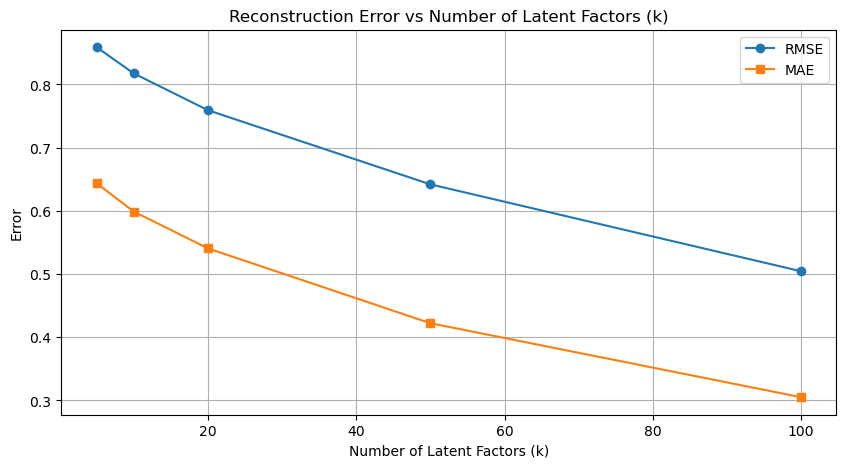

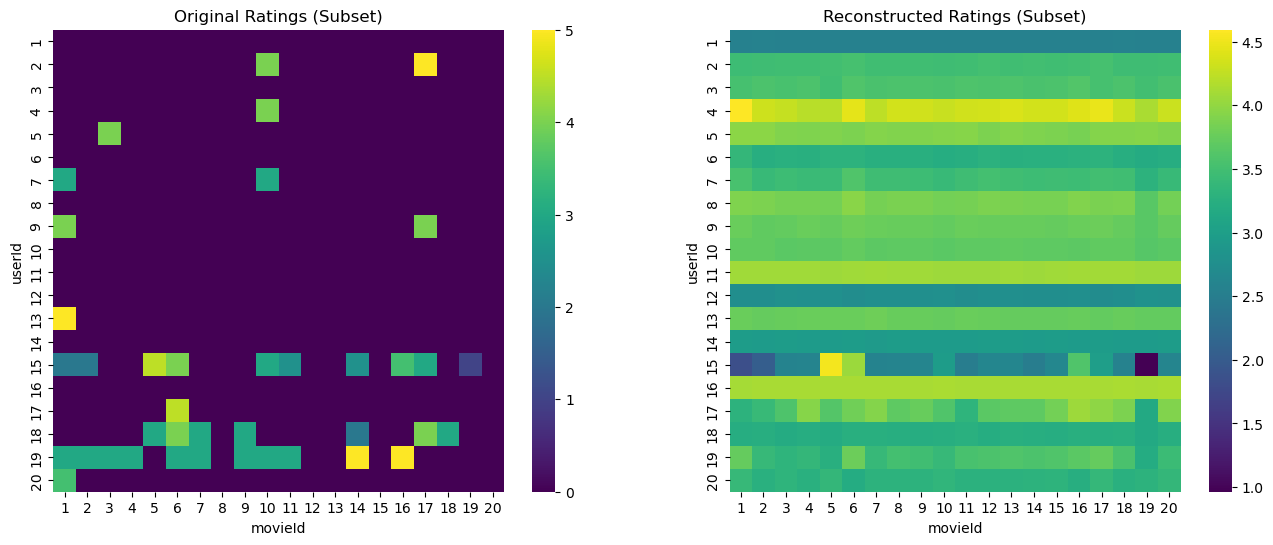

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, rmse_list, marker='o', label='RMSE')
plt.plot(k_values, mae_list, marker='s', label='MAE')
plt.title('Reconstruction Error vs Number of Latent Factors (k)')
plt.xlabel('Number of Latent Factors (k)')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()


subset_actual = user_movie_matrix.iloc[:20, :20].fillna(0)
subset_pred = preds_df.iloc[:20, :20]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(subset_actual, cmap='viridis', ax=ax[0])
ax[0].set_title('Original Ratings (Subset)')

sns.heatmap(subset_pred, cmap='viridis', ax=ax[1])
ax[1].set_title('Reconstructed Ratings (Subset)')
plt.show()


**Scenario 2**

In [19]:

df = pd.read_csv(r'D:\SEM4\ml\lab\dataset\10th\ratings.csv')
movies_df = pd.read_csv(r'D:\SEM4\ml\lab\dataset\10th\movies.csv') 


print(f"Total ratings: {len(df)}")

Total ratings: 100004


In [20]:
user_movie_matrix = df.pivot(index='userId', columns='movieId', values='rating')
R = user_movie_matrix.fillna(0).values

print(f"User-Item Matrix Shape: {R.shape}")

User-Item Matrix Shape: (671, 9066)


In [21]:
k_latent_features = 20 
nmf_model = NMF(n_components=k_latent_features, init='random', random_state=42, max_iter=500)

W = nmf_model.fit_transform(R) 
H = nmf_model.components_     

print(f"Shape of W (User-Features): {W.shape}")
print(f"Shape of H (Item-Features): {H.shape}")

R_predicted = np.dot(W, H)
preds_df = pd.DataFrame(R_predicted, index=user_movie_matrix.index, columns=user_movie_matrix.columns)

Shape of W (User-Features): (671, 20)
Shape of H (Item-Features): (20, 9066)


In [22]:
def get_nmf_recommendations(preds_df, user_id, original_df, movies_df, top_n=5):
    user_preds = preds_df.loc[user_id].sort_values(ascending=False)
    user_rated = original_df[original_df['userId'] == user_id]['movieId'].tolist()
    
    unseen_preds = user_preds[~user_preds.index.isin(user_rated)]
    
    top_movie_ids = unseen_preds.head(top_n).index
    top_scores = unseen_preds.head(top_n).values
    
    recs = movies_df[movies_df['movieId'].isin(top_movie_ids)].copy()
    recs['Predicted_Rating'] = top_scores
    
    return recs.sort_values(by='Predicted_Rating', ascending=False)

top_recs = get_nmf_recommendations(preds_df, user_id=1, original_df=df, movies_df=movies_df, top_n=5)
print("Top 5 NMF Recommendations for User 1:\n", top_recs[['title', 'Predicted_Rating']])

Top 5 NMF Recommendations for User 1:
                                                  title  Predicted_Rating
953  Star Wars: Episode V - The Empire Strikes Back...          0.152903
955  Raiders of the Lost Ark (Indiana Jones and the...          0.143250
966  Star Wars: Episode VI - Return of the Jedi (1983)          0.140674
970                                       Alien (1979)          0.138499
994                             Terminator, The (1984)          0.131160


In [23]:
mask = user_movie_matrix.values > 0
actual_ratings = user_movie_matrix.values[mask]
predicted_ratings = R_predicted[mask]

rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))
print(f"NMF RMSE: {rmse:.4f}")

def precision_recall_at_k(predictions, actuals, k=10, threshold=3.5):
    user_precisions = []
    user_recalls = []
    
    for i in range(len(actuals)):
        top_k_pred_idx = np.argsort(predictions[i])[::-1][:k]
        relevant_actual_idx = np.where(actuals[i] >= threshold)[0]
        
        if len(relevant_actual_idx) == 0:
            continue 
            
        hits = len(set(top_k_pred_idx).intersection(set(relevant_actual_idx)))
        
        user_precisions.append(hits / k)
        user_recalls.append(hits / len(relevant_actual_idx))
        
    return np.mean(user_precisions), np.mean(user_recalls)

p_at_k, r_at_k = precision_recall_at_k(R_predicted, user_movie_matrix.values, k=10)
print(f"Precision@10: {p_at_k:.4f}")
print(f"Recall@10: {r_at_k:.4f}")

NMF RMSE: 2.5304
Precision@10: 0.5426
Recall@10: 0.1176


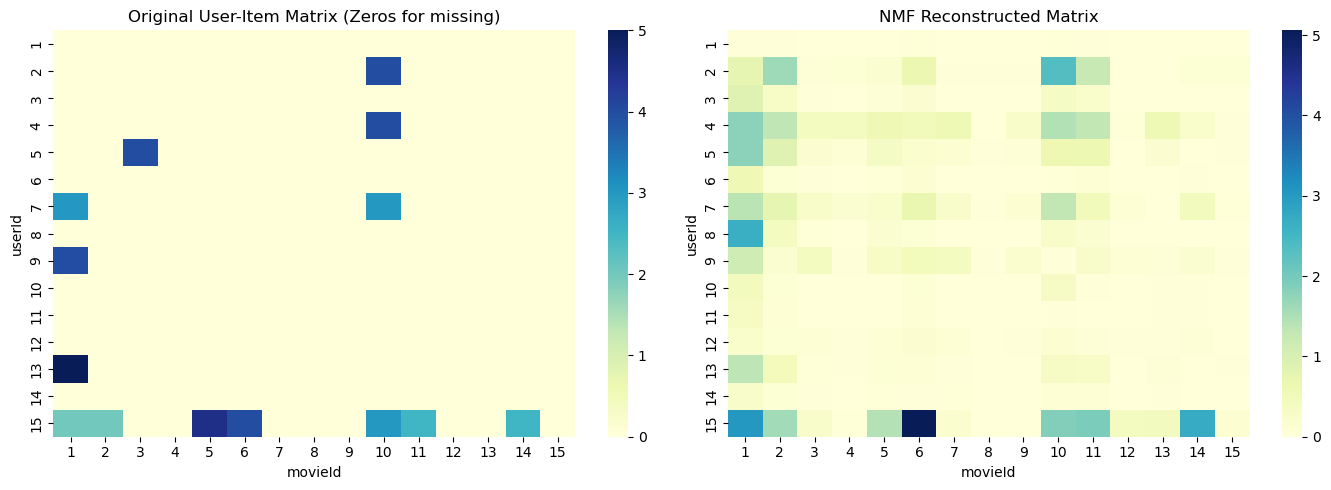

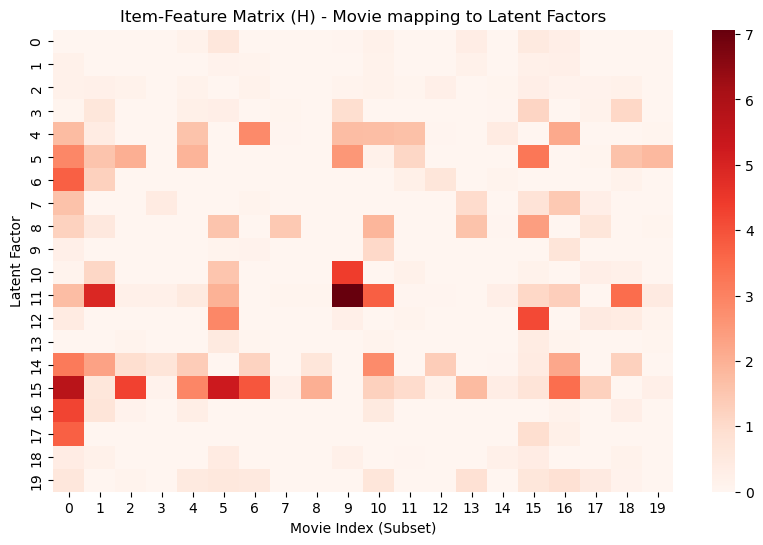

C:\Users\PRAVEENGOVIND\AppData\Local\Temp\ipykernel_15952\1541541821.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_Rating', y='title', data=top_recs, palette='viridis')


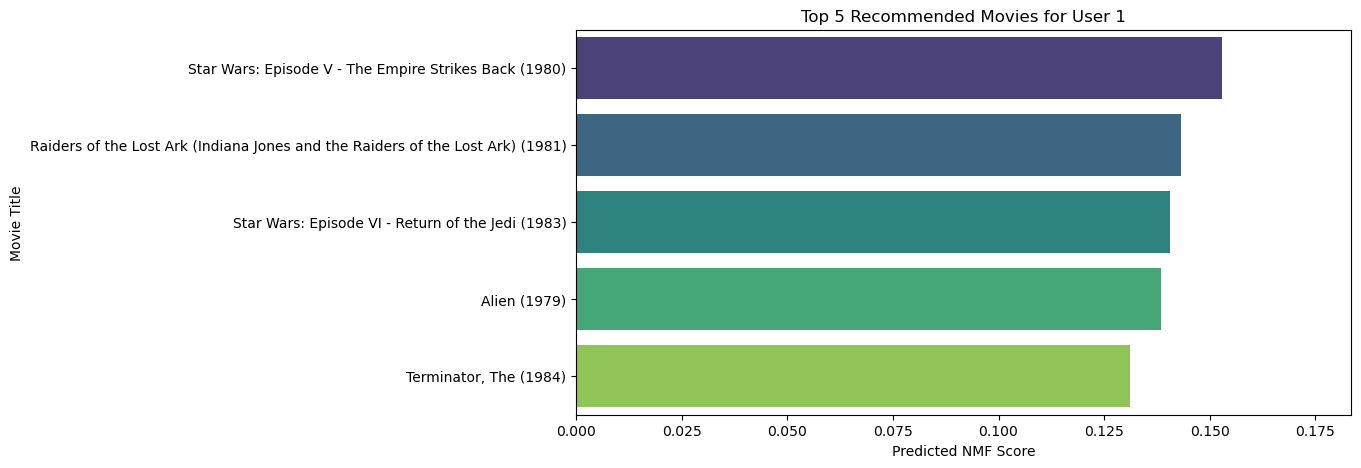

Nitheeswaran M 24BAD079


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(user_movie_matrix.iloc[:15, :15].fillna(0), cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Original User-Item Matrix (Zeros for missing)')

sns.heatmap(preds_df.iloc[:15, :15], cmap='YlGnBu', ax=ax[1])
ax[1].set_title('NMF Reconstructed Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(H[:, :20], cmap='Reds', cbar=True)
plt.title('Item-Feature Matrix (H) - Movie mapping to Latent Factors')
plt.xlabel('Movie Index (Subset)')
plt.ylabel('Latent Factor')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='Predicted_Rating', y='title', data=top_recs, palette='viridis')
plt.title('Top 5 Recommended Movies for User 1')
plt.xlabel('Predicted NMF Score')
plt.ylabel('Movie Title')
plt.xlim(0, max(top_recs['Predicted_Rating']) * 1.2)
plt.show()